# Student Exam Performance — Exploratory Data Analysis

**Course:** IEE 578 Regression Analysis (Spring 2026)
**Team:** Abhi Sachdeva, Amanda Hightower, Abishek Balasubramanian

**Purpose:** justify which predictors enter the regression model. Each numeric predictor is tested for linear correlation with the target; each categorical predictor is tested for group-mean separation via one-way ANOVA. The final cell recommends the predictor set for the modeling pipeline.

**Response variable:** `Exam_Score` (continuous, 55–101).

**Dataset:** Kaggle — Student Exam Performance Factors (~6600 rows, 20 columns).

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning.preprocess import preprocess
from data_cleaning.helpers.types import infer_column_types
from data_cleaning.helpers.outliers import flag_outliers
from exploratory_analysis.helpers.stats import (
    describe_numeric,
    pearson_correlations,
    correlation_matrix,
    compute_vif,
    group_means,
    anova_f_test,
    categorical_signal_report,
)
from exploratory_analysis.helpers.visualize import (
    plot_target_distribution,
    plot_numeric_distributions,
    plot_scatter_vs_target,
    plot_correlation_heatmap,
    plot_correlation_bar,
    plot_categorical_vs_target,
    plot_boxplots,
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

TARGET = 'Exam_Score'
DATA_PATH = PROJECT_ROOT / 'data' / 'StudentPerformanceFactors.csv'

## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded 6,607 rows x 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. Preprocessing

Drops exact-duplicate rows, reports missing values, drops any rows with a missing target.

In [3]:
df = preprocess(df, target=TARGET)
print(f"Post-cleaning shape: {df.shape}")

Dropped 0 duplicate rows on [all columns] — 6,607 -> 6,607
=== Input: 3 columns with missing values ===
                          Missing Count  Missing %
Parental_Education_Level             90       1.36
Teacher_Quality                      78       1.18
Distance_from_Home                   67       1.01
Dropped 0 rows with missing Exam_Score
Post-cleaning shape: (6607, 20)


## 4. Column Type Inference

Auto-infer numeric vs categorical predictors (the pipeline does the same thing).

In [4]:
types = infer_column_types(df, exclude=[TARGET])
NUMERIC = types['numeric']
CATEGORICAL = types['categorical']
print(f"Numeric predictors ({len(NUMERIC)}): {NUMERIC}")
print(f"Categorical predictors ({len(CATEGORICAL)}): {CATEGORICAL}")

Numeric predictors (6): ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical predictors (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## 5. Target Distribution

Sanity check that the response variable looks real (not uniform/synthetic). Real exam-score data should show a peaked, right-skewed distribution.

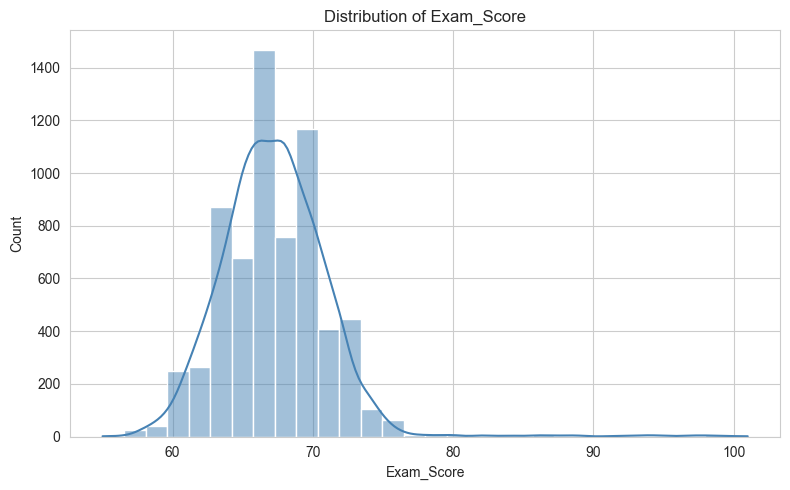

skew:     +1.645
kurtosis: +10.575  (0 = normal, -1.2 = uniform/synthetic)


In [5]:
plot_target_distribution(df, target=TARGET)
print(f"skew:     {df[TARGET].skew():+.3f}")
print(f"kurtosis: {df[TARGET].kurtosis():+.3f}  (0 = normal, -1.2 = uniform/synthetic)")

## 6. Descriptive Statistics

Count, mean, SD, quartiles, skew, kurtosis, and missing counts for all numeric variables.

In [6]:
describe_numeric(df, columns=NUMERIC + [TARGET]).round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing
Hours_Studied,6607.0,19.975,5.991,1.0,16.0,20.0,24.0,44.0,0.013,0.018,0
Attendance,6607.0,79.977,11.547,60.0,70.0,80.0,90.0,100.0,0.014,-1.194,0
Sleep_Hours,6607.0,7.029,1.468,4.0,6.0,7.0,8.0,10.0,-0.024,-0.504,0
Previous_Scores,6607.0,75.071,14.400,50.0,63.0,75.0,88.0,100.0,-0.004,-1.191,0
Tutoring_Sessions,6607.0,1.494,1.231,0.0,1.0,1.0,2.0,8.0,0.816,0.644,0
Physical_Activity,6607.0,2.968,1.031,0.0,2.0,3.0,4.0,6.0,-0.031,-0.059,0
Exam_Score,6607.0,67.236,3.890,55.0,65.0,67.0,69.0,101.0,1.645,10.575,0


## 7. Numeric Predictors — Distributions

Histograms for each numeric predictor. Looking for: skew, bimodality, heavy tails, narrow ranges.

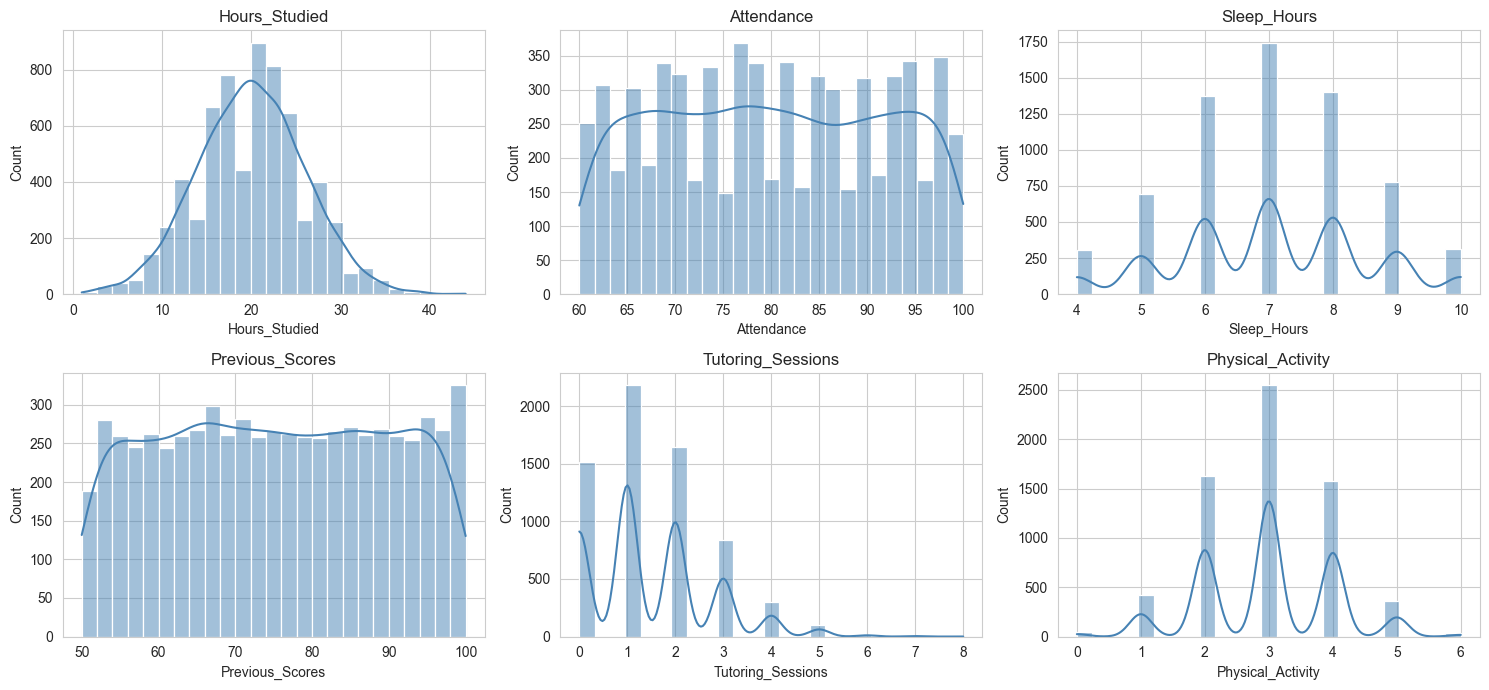

In [7]:
plot_numeric_distributions(df, columns=NUMERIC, ncols=3)

## 8. Numeric Predictors — Correlation With Target

Ranks each numeric predictor by Pearson r with `Exam_Score`. Strong correlations (|r| > 0.3) are strong candidates for the regression model.

In [8]:
num_corr = pearson_correlations(df, target=TARGET, predictors=NUMERIC)
print(num_corr.round(4))

Attendance           0.5811
Hours_Studied        0.4455
Previous_Scores      0.1751
Tutoring_Sessions    0.1565
Physical_Activity    0.0278
Sleep_Hours         -0.0170
Name: Exam_Score, dtype: float64


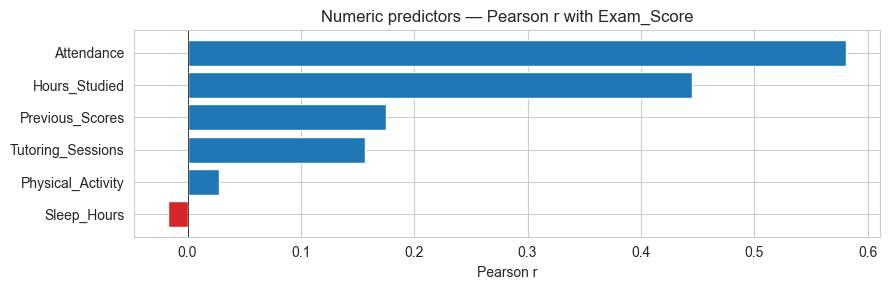

In [9]:
plot_correlation_bar(num_corr, title=f"Numeric predictors — Pearson r with {TARGET}")

## 9. Numeric Predictors — Scatter vs Target

Visual check of linearity and variance structure for each numeric predictor.

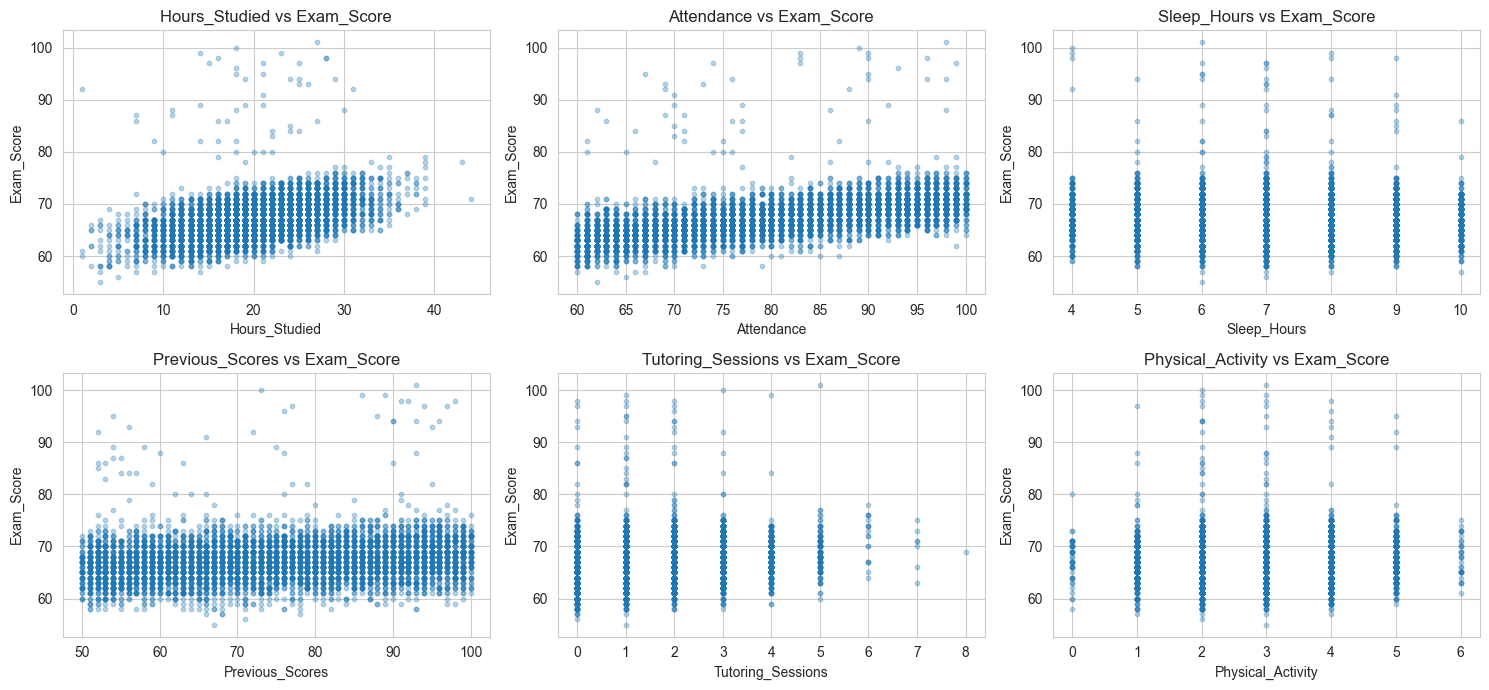

In [10]:
plot_scatter_vs_target(df, predictors=NUMERIC, target=TARGET, ncols=3)

## 10. Numeric Predictors — Correlation Matrix

Pairwise correlations among numeric predictors. Pairs with |r| > 0.7 would raise multicollinearity concerns.

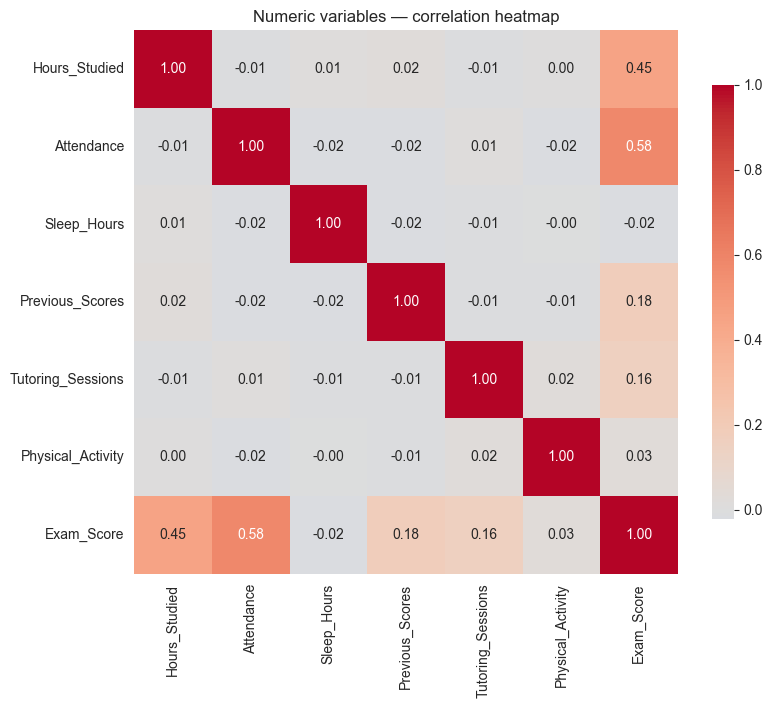

In [11]:
corr = correlation_matrix(df, columns=NUMERIC + [TARGET])
plot_correlation_heatmap(corr, title="Numeric variables — correlation heatmap")

## 11. Categorical Predictors — Signal Report

One-way ANOVA F-test per categorical predictor: does the target mean differ significantly across levels? The larger the F-statistic and smaller the p-value, the more signal the predictor carries.

`group_mean_range` shows how far apart the level-wise means are — larger range = stronger predictor.

In [12]:
cat_report = categorical_signal_report(df, categoricals=CATEGORICAL, target=TARGET)
cat_report.round(4)

,predictor,n_levels,group_mean_min,group_mean_max,group_mean_range,anova_f,anova_p
0,Access_to_Resources,3,66.203,68.092,1.889,98.0044,0.0000
1,Parental_Involvement,3,66.358,68.093,1.735,84.4877,0.0000
2,Learning_Disabilities,2,66.271,67.349,1.078,48.1434,0.0000
3,Parental_Education_Level,3,66.894,67.971,1.077,36.4272,0.0000
4,Peer_Influence,3,66.564,67.623,1.059,34.0521,0.0000
5,Family_Income,3,66.848,67.842,0.994,29.7939,0.0000
6,Extracurricular_Activities,2,66.931,67.442,0.511,27.4917,0.0000
7,Distance_from_Home,3,66.457,67.512,1.055,27.3593,0.0000
8,Motivation_Level,3,66.752,67.704,0.952,25.7168,0.0000
9,Teacher_Quality,3,66.753,67.677,0.924,19.6394,0.0000


## 12. Categorical Predictors — Boxplots by Target

Visual confirmation of the ANOVA results. Clear box separation between levels = strong categorical signal.

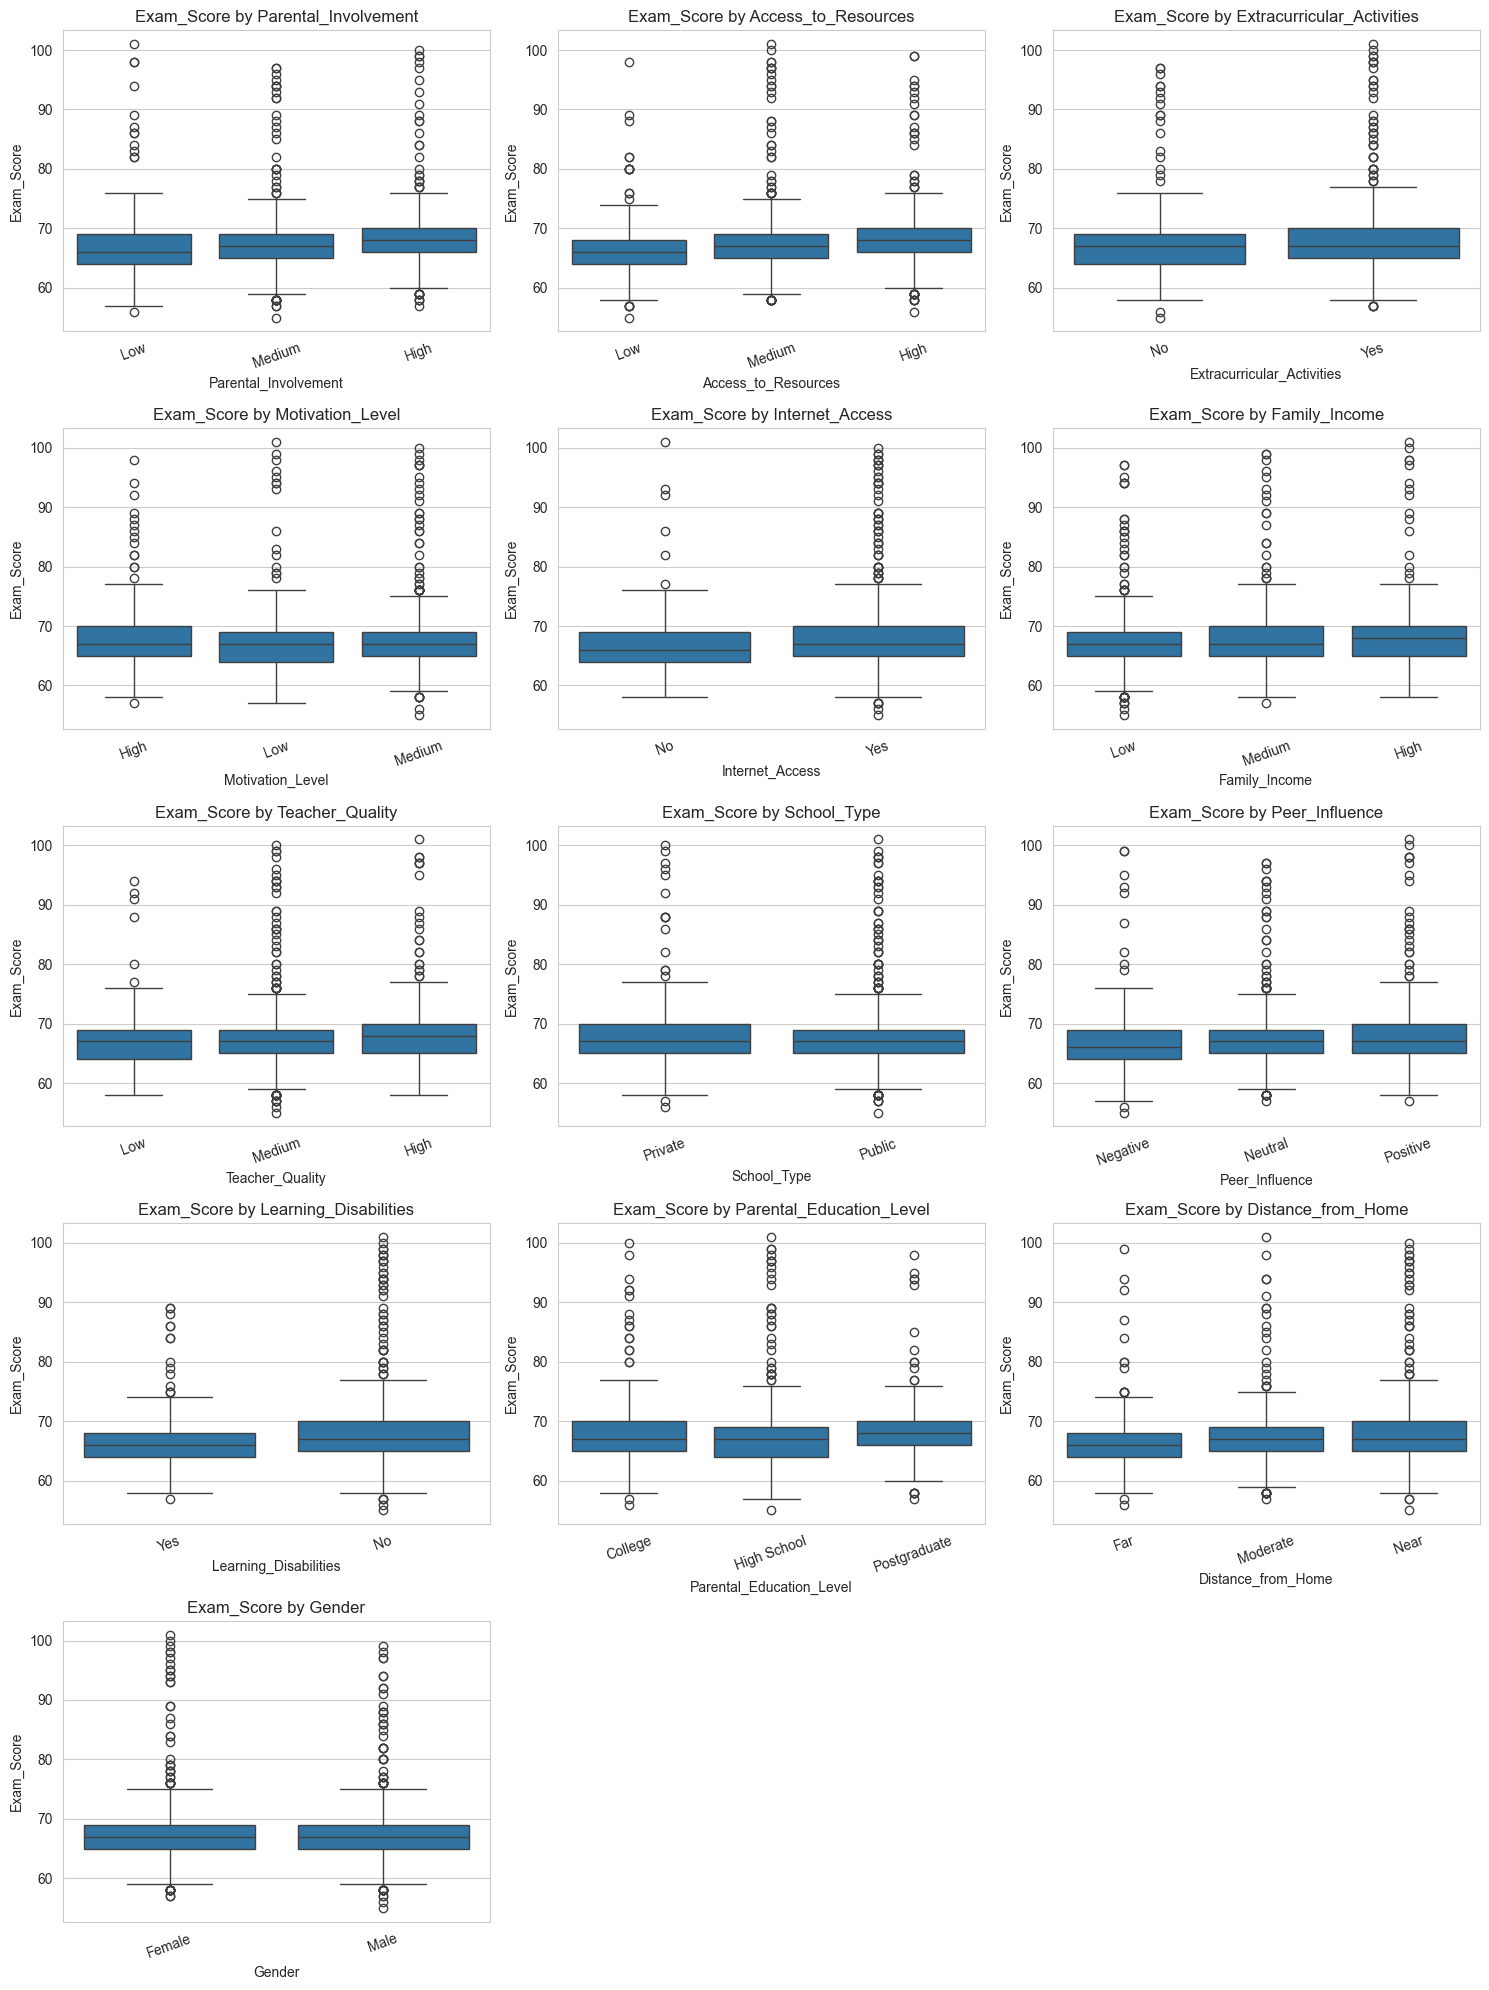

In [13]:
plot_categorical_vs_target(df, categoricals=CATEGORICAL, target=TARGET, ncols=3)

## 13. Outlier Assessment (numeric)

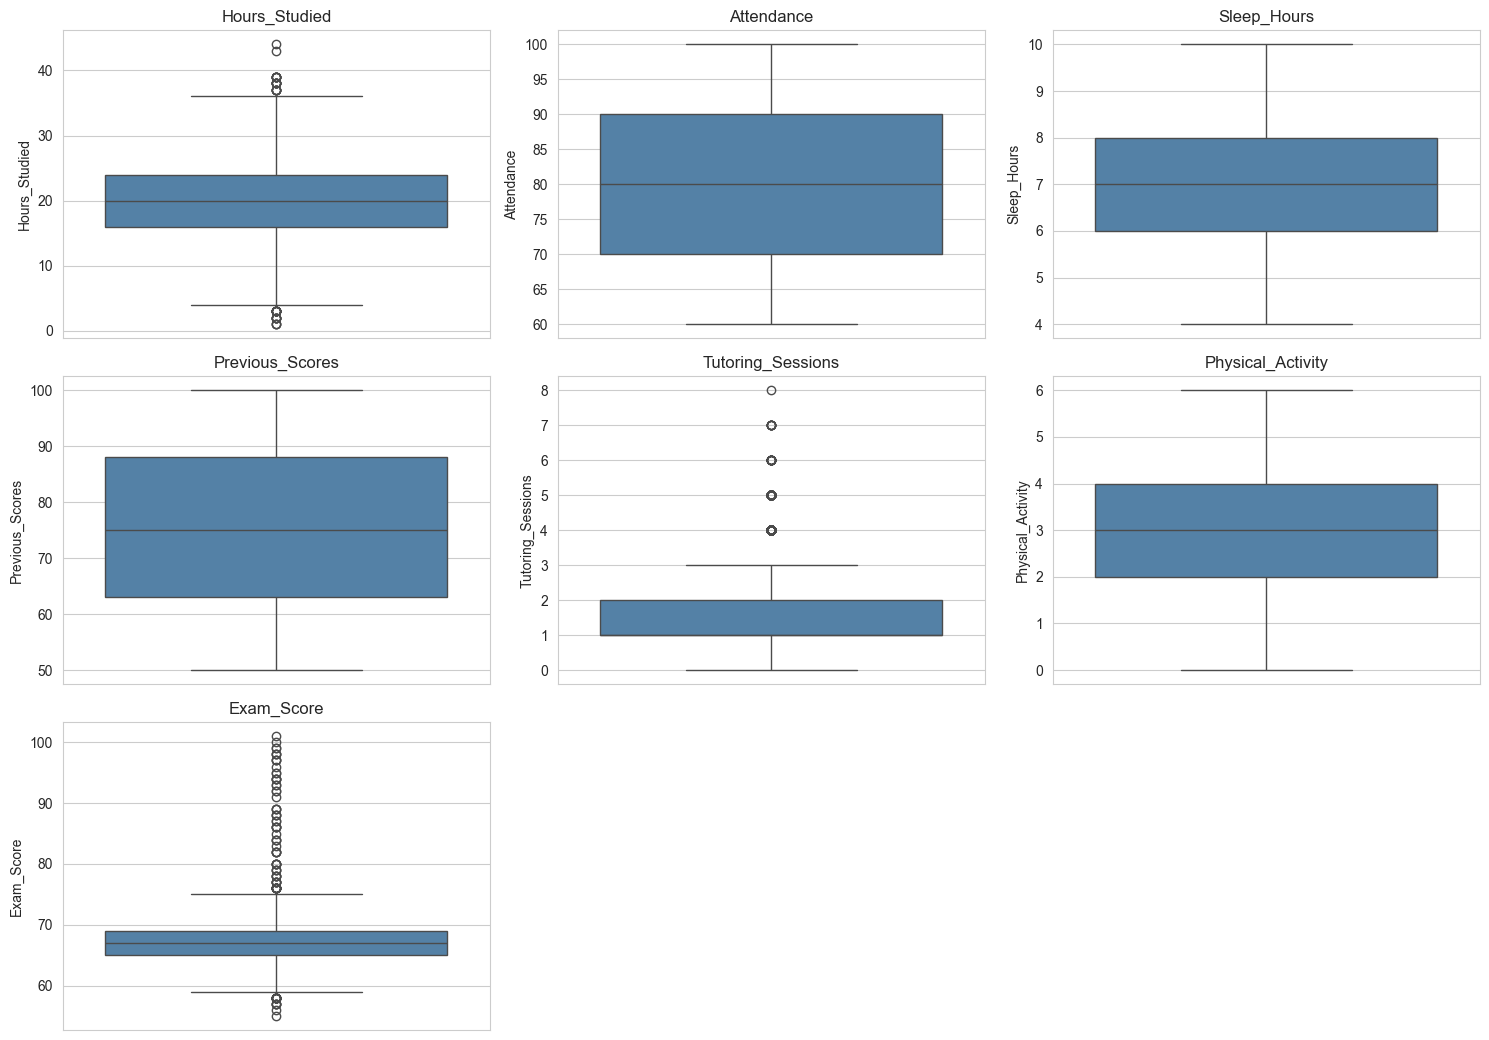

Hours_Studied: 43 outliers flagged (0.7%) — bounds [4.00, 36.00]
Attendance: 0 outliers flagged (0.0%) — bounds [40.00, 120.00]
Sleep_Hours: 0 outliers flagged (0.0%) — bounds [3.00, 11.00]
Previous_Scores: 0 outliers flagged (0.0%) — bounds [25.50, 125.50]
Tutoring_Sessions: 430 outliers flagged (6.5%) — bounds [-0.50, 3.50]
Physical_Activity: 0 outliers flagged (0.0%) — bounds [-1.00, 7.00]


In [14]:
plot_boxplots(df, columns=NUMERIC + [TARGET], ncols=3)
for col in NUMERIC:
    df = flag_outliers(df, col)

## 14. Multicollinearity — VIF on numeric predictors

In [15]:
compute_vif(df, predictors=NUMERIC).round(3)

,predictor,VIF
3,Previous_Scores,1.002
1,Attendance,1.001
0,Hours_Studied,1.001
4,Tutoring_Sessions,1.001
2,Sleep_Hours,1.001
5,Physical_Activity,1.001


## 15. Recommended Predictor Set

Predictors are recommended for the regression pipeline based on the results above:
- **Numeric predictors:** include any with |r| ≥ 0.10 against `Exam_Score` (the threshold is soft — we'll let stepwise selection refine).
- **Categorical predictors:** include any with ANOVA p-value < 0.05 — evidence that group means differ non-trivially.

The pipeline (`modeling/fit_model.py`) will automatically one-hot encode the selected categoricals and fit MLR / Ridge / Lasso.

In [16]:
# Numeric keeps: |r| >= 0.10
recommended_numeric = num_corr[num_corr.abs() >= 0.10].index.tolist()

# Categorical keeps: ANOVA p < 0.05
recommended_categorical = cat_report[cat_report['anova_p'] < 0.05]['predictor'].tolist()

print('Recommended numeric predictors:')
for c in recommended_numeric:
    print(f'  {c:<25} r = {num_corr[c]:+.4f}')
print()
print('Recommended categorical predictors:')
for c in recommended_categorical:
    p = cat_report.set_index('predictor').loc[c, 'anova_p']
    print(f'  {c:<30} ANOVA p = {p:.2e}')

Recommended numeric predictors:
  Attendance                r = +0.5811
  Hours_Studied             r = +0.4455
  Previous_Scores           r = +0.1751
  Tutoring_Sessions         r = +0.1565

Recommended categorical predictors:
  Access_to_Resources            ANOVA p = 1.14e-42
  Parental_Involvement           ANOVA p = 5.88e-37
  Learning_Disabilities          ANOVA p = 4.34e-12
  Parental_Education_Level       ANOVA p = 1.85e-16
  Peer_Influence                 ANOVA p = 1.94e-15
  Family_Income                  ANOVA p = 1.31e-13
  Extracurricular_Activities     ANOVA p = 1.63e-07
  Distance_from_Home             ANOVA p = 1.47e-12
  Motivation_Level               ANOVA p = 7.49e-12
  Teacher_Quality                ANOVA p = 3.14e-09
  Internet_Access                ANOVA p = 2.84e-05
